In [ ]:
pip install matplotlib

In [ ]:
pip install pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import random

In [ ]:
ruta= r"Titanic.csv"
#guardar la ruta

In [ ]:
df= pd.read_csv(ruta)
#leer a ruta

In [ ]:
df.info()
#informacion general del dataframe

## 1 Pasajeros sobrevivientes por clase

In [48]:
df["Pclass"].nunique()
#cuantos valores unicos existen en tal columna

3

In [49]:
#cuenta el total de personas de cada clase y los que sobrevivieron de la respectiva clase
sobrevivientesxclase = df.groupby('Pclass')['Survived'].agg(['sum', 'count'])
#count representa la cantidad de pasajeros que habia de esa clase y sum los que sobrevivieron 
print(sobrevivientesxclase)


        sum  count
Pclass            
1        50    107
2        30     93
3        72    218


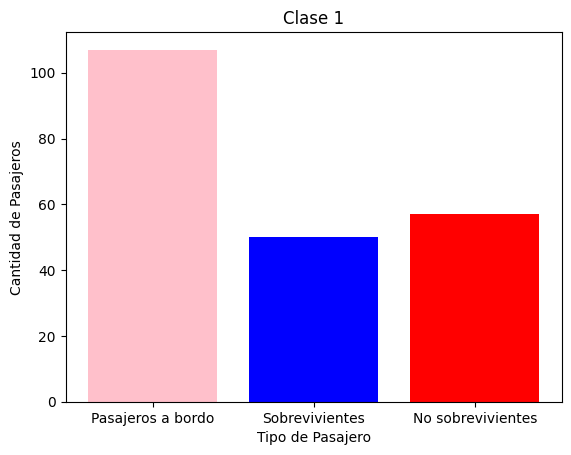

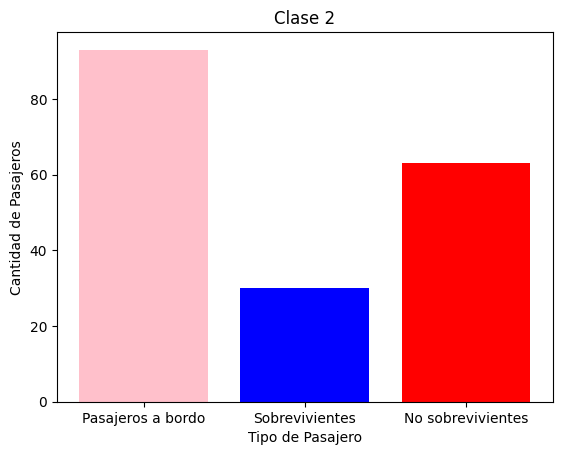

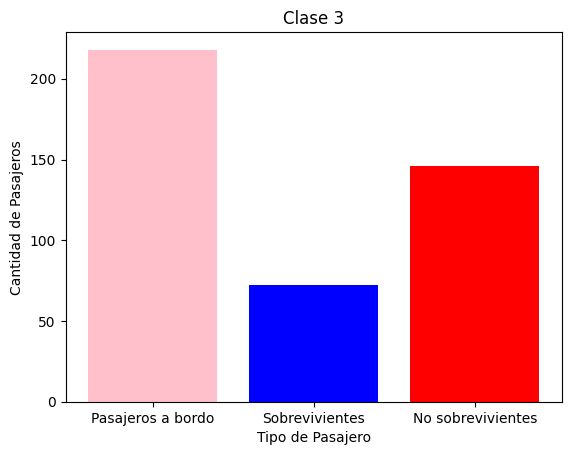

La clase con mayor proporcion de sobrevivientes fue:
Clase 1
Con un 46.73% de sobrevivientes de esta clase


In [50]:
# Gráfico de barras: Personas con hijos que sobrevivieron
# Datos por clase
#clase1
x1 = ['Pasajeros a bordo','Sobrevivientes', "No sobrevivientes"]
y1 = [107, 50, 57]
sob1=y1[1]/y1[0]
colores = ['pink', 'blue', "red"]
plt.bar(x1, y1, color=colores)
plt.xlabel('Tipo de Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Clase 1')

# Mostrar el gráfico
plt.show()

#clase2
x2 = ['Pasajeros a bordo','Sobrevivientes', "No sobrevivientes"]
y2 = [93, 30, 63]
sob2=y2[1]/y2[0]
colores = ['pink', 'blue', "red"]
plt.bar(x2, y2, color=colores)
plt.xlabel('Tipo de Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Clase 2')
# Mostrar el gráfico
plt.show()

#clase3
x3 = ['Pasajeros a bordo','Sobrevivientes', "No sobrevivientes"]
y3 = [218, 72,146]
sob3=y3[1]/y3[0]
colores = ['pink', 'blue', "red"]
plt.bar(x3, y3, color=colores)
plt.xlabel('Tipo de Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Clase 3')
# Mostrar el gráfico
plt.show()

# Clase con mas sobrevivientes 
mas_sob= max(sob3,sob1, sob2)
print("La clase con mayor proporcion de sobrevivientes fue:")
if mas_sob==sob1:
    print("Clase 1")
elif mas_sob==sob2:
    print("Clase 2")
else:
    print("Clase 3")

print(f"Con un {mas_sob*100:.2f}% de sobrevivientes de esta clase")


## Ejercicio 2

### 2.1 GrupoEdad

In [51]:
def GrupoEdad(Age):
    if pd.isna(Age):
        return 'Desconocido'
    elif Age < 18.0:
        return 'Menor'
    elif Age <=59.0:
        return 'Adulto'
    elif Age >= 60.0:
        return 'Mayor'

In [52]:
df['GrupoEdad'] = df['Age'].apply(GrupoEdad)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GrupoEdad,Familia
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Adulto,False
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adulto,True
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mayor,False
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Adulto,False
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Adulto,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Desconocido,False
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Adulto,False
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Adulto,False
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Desconocido,False


## 2.2 Pasajeros sobreviviente por grupo de edad

In [53]:
#cuenta el total de personas de cada Grupo de edad y los que sobrevivieron del respectivo grupo
sobreviGE = df.groupby('GrupoEdad')['Survived'].agg(['sum', 'count'])
sobreviGE

,sum,count
GrupoEdad,,
Adulto,103,277
Desconocido,25,86
Mayor,7,14
Menor,17,41


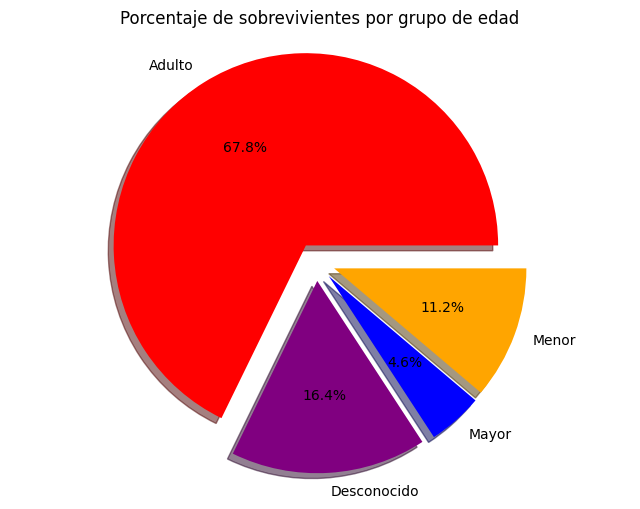

In [54]:
#porcentajes para la grafica de pastel
total= sobreviGE["sum"].sum()
grupo = ['Adulto', 'Desconocido', 'Mayor', 'Menor']
per_xgrup = [103, 25, 7, 17]
colores = ['red', 'purple', 'blue', 'orange']
explode = (0.1, 0.1, 0.1, 0.1)
# Configurar tamaño del gráfico
plt.figure(figsize=(8, 6))
plt.pie(per_xgrup,labels=grupo,colors=colores,explode=explode ,shadow=True, autopct='%1.1f%%')
plt.title('Porcentaje de sobrevivientes por grupo de edad')
plt.axis('equal')  # Mantiene proporciones circulares
plt.show()

## 2.3 Familia

In [55]:
#checa si viajo con algun acompañante, ya sea hermanos, conyuges, padres o hijos
df['Familia'] = df.apply(lambda row: True if (row['SibSp'] + row['Parch']) > 0 else False,axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GrupoEdad,Familia
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Adulto,False
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adulto,True
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mayor,False
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Adulto,False
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Adulto,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Desconocido,False
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Adulto,False
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Adulto,False
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Desconocido,False


## 2.4 Adultos acompañados 

In [56]:
# Generamos un dataframe con los adultos unicamente para facilidad de lso siguientes problemas
adultos = df[df['GrupoEdad'] == 'Adulto']
adultos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,GrupoEdad,Familia
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Adulto,False
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adulto,True
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Adulto,False
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Adulto,True
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,Adulto,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C,Adulto,True
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,Adulto,True
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,Adulto,False
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Adulto,False


In [57]:
adultos_acompañados = adultos[adultos['Familia'] == True]
print("Adultos acompañados:", len(adultos_acompañados))

Adultos acompañados: 104


## 2.5 Adultos sobrevivientes

In [58]:
adultos_sobrevivientes = adultos[adultos['Survived'] == 1]
print("La cantidad de adultos que sobrevivieron:", len(adultos_sobrevivientes))

La cantidad de adultos que sobrevivieron: 103


## 2.6 - Sexo más común 

In [59]:
sexo_mas_comun = adultos_sobrevivientes['Sex'].mode()[0]
print(" Sexo más común entre adultos sobrevivientes:", sexo_mas_comun)


 Sexo más común entre adultos sobrevivientes: female


## 2.7 Adultos sobrevivientes solos o acompañados 

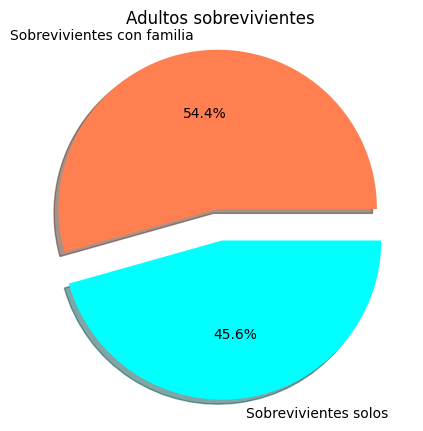

In [62]:
#Grafica de pastel
sobrevivientes_adultos = adultos[adultos['Survived'] == 1]
con_familia = sobrevivientes_adultos[sobrevivientes_adultos['Familia'] == True]
solos = sobrevivientes_adultos[sobrevivientes_adultos['Familia'] == False]

# Conteos
sobrevivienets_conosin = [len(con_familia), len(solos)]
etiquetas = ['Sobrevivientes con familia', 'Sobrevivientes solos']
explode = (0.1, 0.1)
# Graficar
plt.figure(figsize=(5,5))
plt.pie(sobrevivienets_conosin, labels=etiquetas, autopct='%1.1f%%', colors=["coral", "cyan"], shadow=True, explode=explode)
plt.title('Adultos sobrevivientes')
plt.axis('equal') 
plt.show()
